# Collecte de Données Financières - SentiTrade-HMA v2.0

**Période:** 2018-2024 (6 ans incluant COVID)  
**Tickers:** 20 minimum (Top S&P 500 diversifiés)  
**Objectif:** Collecter les données OHLCV depuis Yahoo Finance


In [1]:
# Setup du projet
import sys
from pathlib import Path

# Déterminer le dossier racine
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json

from src.utils.config import get_config
from src.utils.logger import get_logger
from src.data.collectors import FinancialDataCollector

# Configuration matplotlib
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

logger = get_logger(__name__)

print("✅ Imports réussis")
print(f"📁 Project root: {project_root}")


✅ Imports réussis
📁 Project root: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2


In [3]:
# Charger la configuration depuis les YAML
config = get_config()
data_config = config.get_data_config()

# Lire les tickers depuis config
tickers = data_config['tickers']['main']

# Lire les dates depuis config
financial_config = data_config['data_sources']['financial']
start_date = financial_config['start_date']
end_date = financial_config['end_date']

print("="*70)
print(" CONFIGURATION DE LA COLLECTE")
print("="*70)
print(f"Nombre de tickers: {len(tickers)}")
print(f"Liste des tickers: {tickers}")
print(f"Période: {start_date} → {end_date}")
print("="*70)


 CONFIGURATION DE LA COLLECTE
Nombre de tickers: 20
Liste des tickers: ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META', 'AMZN', 'TSLA', 'WMT', 'JPM', 'BAC', 'V', 'JNJ', 'UNH', 'PFE', 'XOM', 'CVX', 'BA', 'CAT', 'VZ', 'T']
Période: 2018-01-02 → 2024-12-31


In [4]:
# Calculer durée et volume attendu
start = datetime.strptime(start_date, '%Y-%m-%d')
end = datetime.strptime(end_date, '%Y-%m-%d')
years = (end - start).days / 365.25
trading_days_expected = int(years * 252)

print(f" Analyse de la période:")
print(f"  - Durée: {years:.2f} années")
print(f"  - Jours trading attendus: ~{trading_days_expected}")
print(f"  - Lignes totales attendues: ~{trading_days_expected * len(tickers):,}")
print()

# Analyser la diversification
sectors = {
    'Tech': ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META'],
    'E-commerce': ['AMZN'],
    'Automobile': ['TSLA'],
    'Retail': ['WMT'],
    'Finance': ['JPM', 'BAC', 'V'],
    'Santé': ['JNJ', 'UNH', 'PFE'],
    'Énergie': ['XOM', 'CVX'],
    'Industrie': ['BA', 'CAT'],
    'Télécom': ['VZ', 'T']
}

print(" Diversification sectorielle:")
ticker_set = set(tickers)
for sector, sector_tickers in sectors.items():
    count = len([t for t in sector_tickers if t in ticker_set])
    if count > 0:
        print(f"  - {sector}: {count} ticker(s)")


 Analyse de la période:
  - Durée: 7.00 années
  - Jours trading attendus: ~1762
  - Lignes totales attendues: ~35,240

 Diversification sectorielle:
  - Tech: 5 ticker(s)
  - E-commerce: 1 ticker(s)
  - Automobile: 1 ticker(s)
  - Retail: 1 ticker(s)
  - Finance: 3 ticker(s)
  - Santé: 3 ticker(s)
  - Énergie: 2 ticker(s)
  - Industrie: 2 ticker(s)
  - Télécom: 2 ticker(s)


In [5]:
# Vérification conformité fiche de projet
print()
print("✅ CONFORMITÉ FICHE DE PROJET:")
issues = []

if start_date != "2018-01-02":
    issues.append(f"❌ Date début: {start_date} (devrait être 2018-01-02)")
else:
    print(f"  ✅ Date début: {start_date} (conforme)")

if years < 6:
    issues.append(f"❌ Durée: {years:.1f} ans (< 6 ans requis)")
else:
    print(f"  ✅ Durée: {years:.1f} ans (≥6 ans requis)")
    print(f"  ✅ COVID inclus: Oui (2020-2021 présents)")

if len(tickers) < 20:
    issues.append(f"⚠️  Tickers: {len(tickers)} (< 20 recommandés)")
else:
    print(f"  ✅ Nombre tickers: {len(tickers)} (≥20 recommandés)")

if issues:
    print("\n⚠️  PROBLÈMES DÉTECTÉS:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("\n🎉 CONFIGURATION 100% CONFORME!")

print("="*70)



✅ CONFORMITÉ FICHE DE PROJET:
  ✅ Date début: 2018-01-02 (conforme)
  ✅ Durée: 7.0 ans (≥6 ans requis)
  ✅ COVID inclus: Oui (2020-2021 présents)
  ✅ Nombre tickers: 20 (≥20 recommandés)

🎉 CONFIGURATION 100% CONFORME!


In [ ]:
# Collecte des données
print("\n DÉBUT DE LA COLLECTE...")
print(f"  Estimation: ~{len(tickers) * 2} secondes")
print()

collector = FinancialDataCollector()
data = collector.collect(tickers, start_date, end_date)

if data.empty:
    print("\n ERREUR: Aucune donnée collectée!")
    print("Vérifiez:")
    print("  1. Connexion internet")
    print("  2. Validité des tickers")
    print("  3. Période demandée")
else:
    print(f"\n COLLECTE TERMINÉE!")
    print(f"  - Lignes collectées: {len(data):,}")
    print(f"  - Tickers réussis: {data['Ticker'].nunique()}/{len(tickers)}")
    print(f"  - Colonnes: {list(data.columns)}")
    print(f"  - Période couverte: {data['Date'].min()} → {data['Date'].max()}")
    
    # Vérifier tickers manquants
    collected_tickers = set(data['Ticker'].unique())
    missing_tickers = set(tickers) - collected_tickers
    if missing_tickers:
        print(f"\n  Tickers non collectés ({len(missing_tickers)}):")
        print(f"  {sorted(missing_tickers)}")



🔄 DÉBUT DE LA COLLECTE...
⏱️  Estimation: ~40 secondes

2026-01-08 13:28:50 - src.data.collectors - INFO - Collecting data for 20 tickers...
2026-01-08 13:28:50 - src.data.collectors - INFO -   Downloading AAPL...
2026-01-08 13:28:51 - src.data.collectors - INFO -    AAPL: 1760 rows
2026-01-08 13:28:51 - src.data.collectors - INFO -   Downloading MSFT...
2026-01-08 13:28:51 - src.data.collectors - INFO -    MSFT: 1760 rows
2026-01-08 13:28:51 - src.data.collectors - INFO -   Downloading GOOGL...
2026-01-08 13:28:51 - src.data.collectors - INFO -    GOOGL: 1760 rows
2026-01-08 13:28:51 - src.data.collectors - INFO -   Downloading NVDA...
2026-01-08 13:28:51 - src.data.collectors - INFO -    NVDA: 1760 rows
2026-01-08 13:28:51 - src.data.collectors - INFO -   Downloading META...
2026-01-08 13:28:52 - src.data.collectors - INFO -    META: 1760 rows
2026-01-08 13:28:52 - src.data.collectors - INFO -   Downloading AMZN...
2026-01-08 13:28:52 - src.data.collectors - INFO -    AMZN: 1760 row

In [8]:
# Aperçu des données
print("\n APERÇU DES DONNÉES:\n")
display(data.head(10))
print("\n...")
display(data.tail(5))



 APERÇU DES DONNÉES:



Price,Date,Close,High,Low,Open,Volume,Ticker
0,2018-01-02,40.341888,40.351258,39.639313,39.850088,102223600,AAPL
1,2018-01-03,40.334858,40.878185,40.271629,40.405116,118071600,AAPL
2,2018-01-04,40.522221,40.625266,40.299739,40.407465,89738400,AAPL
3,2018-01-05,40.983582,41.070231,40.526908,40.618243,94640000,AAPL
4,2018-01-08,40.831348,41.126429,40.732985,40.831348,82271200,AAPL
5,2018-01-09,40.826668,40.997627,40.611212,40.878190,86336000,AAPL
6,2018-01-10,40.817284,40.819628,40.515178,40.552649,95839600,AAPL
7,2018-01-11,41.049145,41.098327,40.864135,40.887552,74670800,AAPL
8,2018-01-12,41.473042,41.536274,41.135805,41.259926,101672400,AAPL
9,2018-01-16,41.262264,42.011677,41.250554,41.662730,118263600,AAPL



...


Price,Date,Close,High,Low,Open,Volume,Ticker
35195,2024-12-23,21.860720,21.889434,21.621439,21.698008,24655600,T
35196,2024-12-24,21.966003,22.004287,21.784149,21.860719,9605900,T
35197,2024-12-26,21.975574,22.157429,21.899005,21.946862,16440500,T
35198,2024-12-27,21.879862,22.080857,21.841576,21.899003,18547500,T
35199,2024-12-30,21.640583,21.803294,21.477872,21.803294,25420000,T


In [9]:
# Statistiques détaillées par ticker
print("\n" + "="*70)
print(" STATISTIQUES PAR TICKER")
print("="*70 + "\n")

stats_list = []
for ticker in sorted(data['Ticker'].unique()):
    ticker_data = data[data['Ticker'] == ticker].sort_values('Date')
    
    first_price = ticker_data['Close'].iloc[0]
    last_price = ticker_data['Close'].iloc[-1]
    min_price = ticker_data['Close'].min()
    max_price = ticker_data['Close'].max()
    
    total_return = ((last_price / first_price) - 1) * 100
    
    stats_list.append({
        'Ticker': ticker,
        'Jours': len(ticker_data),
        'Prix Initial': round(first_price, 2),
        'Prix Final': round(last_price, 2),
        'Min': round(min_price, 2),
        'Max': round(max_price, 2),
        'Rendement Total (%)': round(total_return, 2),
        'Volume Moyen': int(ticker_data['Volume'].mean())
    })

stats_df = pd.DataFrame(stats_list)
display(stats_df)

# Statistiques globales
print("\n STATISTIQUES GLOBALES:")
jours = stats_df['Jours']
print(f"  - Jours min: {jours.min()}")
print(f"  - Jours max: {jours.max()}")
print(f"  - Jours moyen: {jours.mean():.0f}")
print(f"  - Complétude: {(jours.min() / trading_days_expected * 100):.1f}%")

if jours.min() >= trading_days_expected * 0.9:
    print(f"   Qualité: Excellente (≥90% des jours attendus)")
elif jours.min() >= trading_days_expected * 0.8:
    print(f"    Qualité: Bonne (≥80% des jours attendus)")
else:
    print(f"   Qualité: Insuffisante (<80% des jours attendus)")



 STATISTIQUES PAR TICKER



,Ticker,Jours,Prix Initial,Prix Final,Min,Max,Rendement Total (%),Volume Moyen
0,AAPL,1760,40.34,251.06,33.80,257.85,522.34,100176118
1,AMZN,1760,59.45,221.30,59.45,232.93,272.24,76127669
2,BA,1760,282.89,176.55,95.01,430.30,-37.59,10638545
3,BAC,1760,24.78,42.92,15.70,46.43,73.21,53070641
4,CAT,1760,131.85,357.61,81.65,410.68,171.22,3671920
5,CVX,1760,90.33,136.73,41.97,165.55,51.37,8948084
6,GOOGL,1760,53.26,190.49,48.86,195.89,257.68,33809274
7,JNJ,1760,111.35,139.08,94.47,166.51,24.90,7935858
8,JPM,1760,86.34,233.31,67.10,244.00,170.22,13227329
9,META,1760,180.16,589.38,88.29,630.18,227.14,22804765



 STATISTIQUES GLOBALES:
  - Jours min: 1760
  - Jours max: 1760
  - Jours moyen: 1760
  - Complétude: 99.9%
   Qualité: Excellente (≥90% des jours attendus)



 Génération des visualisations...



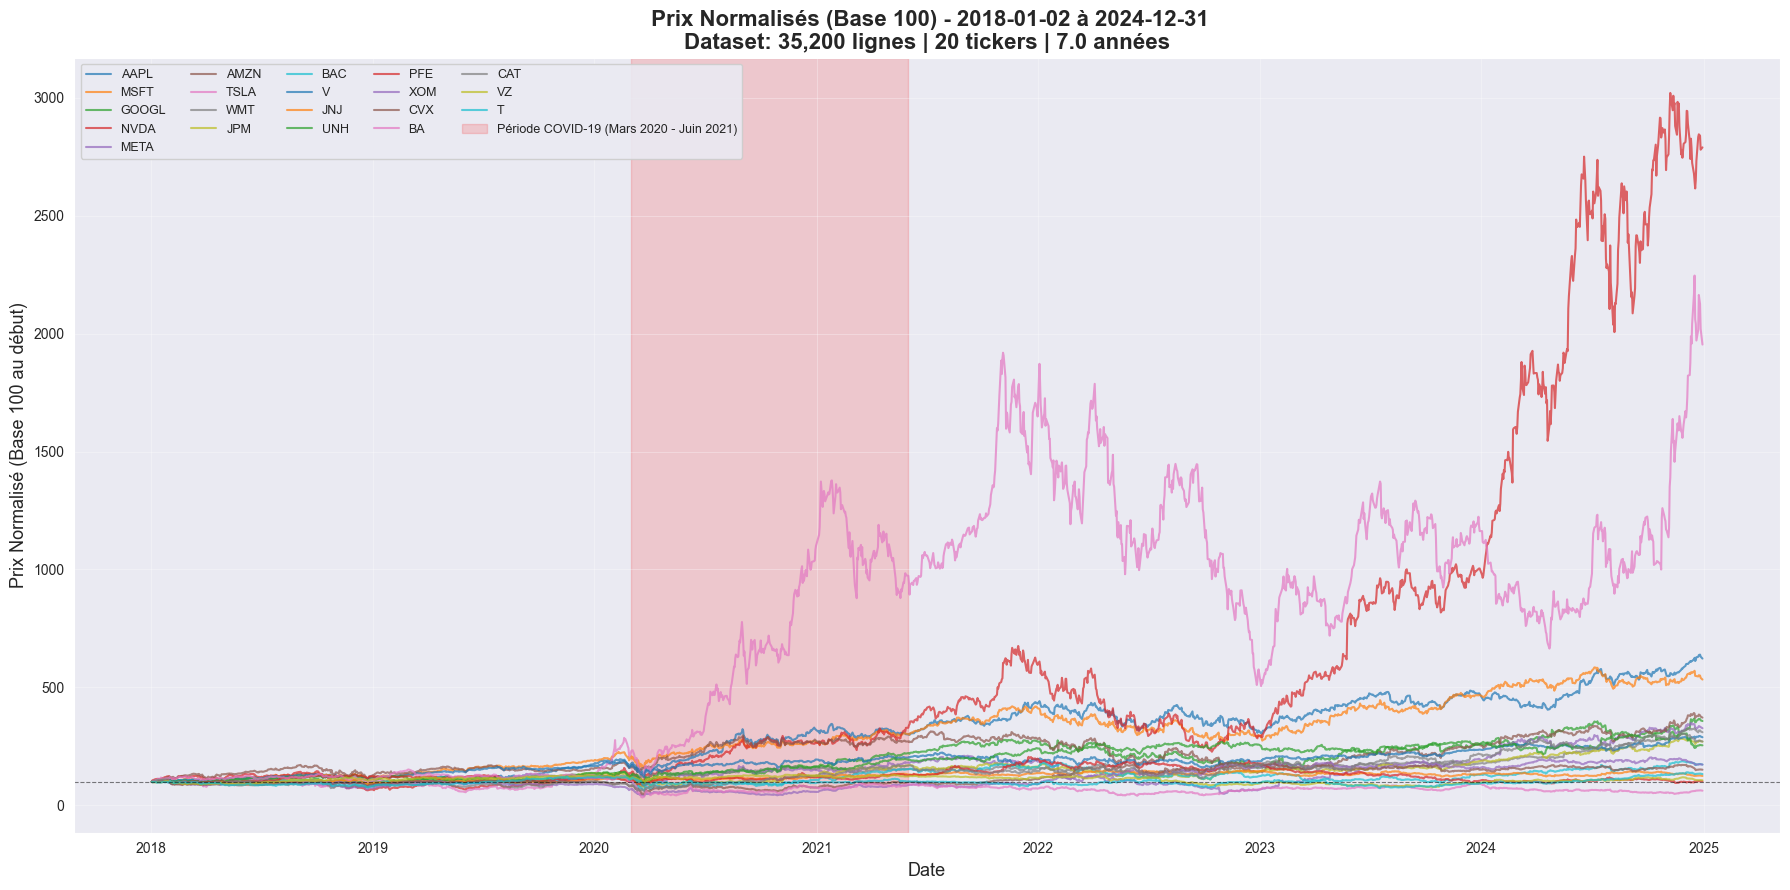

 Graphique 1/4: Prix normalisés avec période COVID


In [10]:
# Visualisation 1: Prix normalisés avec période COVID
print("\n Génération des visualisations...\n")

fig, ax = plt.subplots(figsize=(18, 9))

# Normaliser les prix (base 100)
for ticker in data['Ticker'].unique():
    ticker_data = data[data['Ticker'] == ticker].sort_values('Date')
    ticker_data['Normalized'] = (ticker_data['Close'] / ticker_data['Close'].iloc[0]) * 100
    
    ax.plot(ticker_data['Date'], ticker_data['Normalized'], 
            label=ticker, alpha=0.7, linewidth=1.5)

# Marquer la période COVID-19
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-06-01')
ax.axvspan(covid_start, covid_end, alpha=0.15, color='red', 
           label='Période COVID-19 (Mars 2020 - Juin 2021)', zorder=0)

ax.set_title(f' Prix Normalisés (Base 100) - {start_date} à {end_date}\n' + 
             f'Dataset: {len(data):,} lignes | {data["Ticker"].nunique()} tickers | {years:.1f} années',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Prix Normalisé (Base 100 au début)', fontsize=13)
ax.legend(loc='best', fontsize=9, ncol=5, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

print(" Graphique 1/4: Prix normalisés avec période COVID")


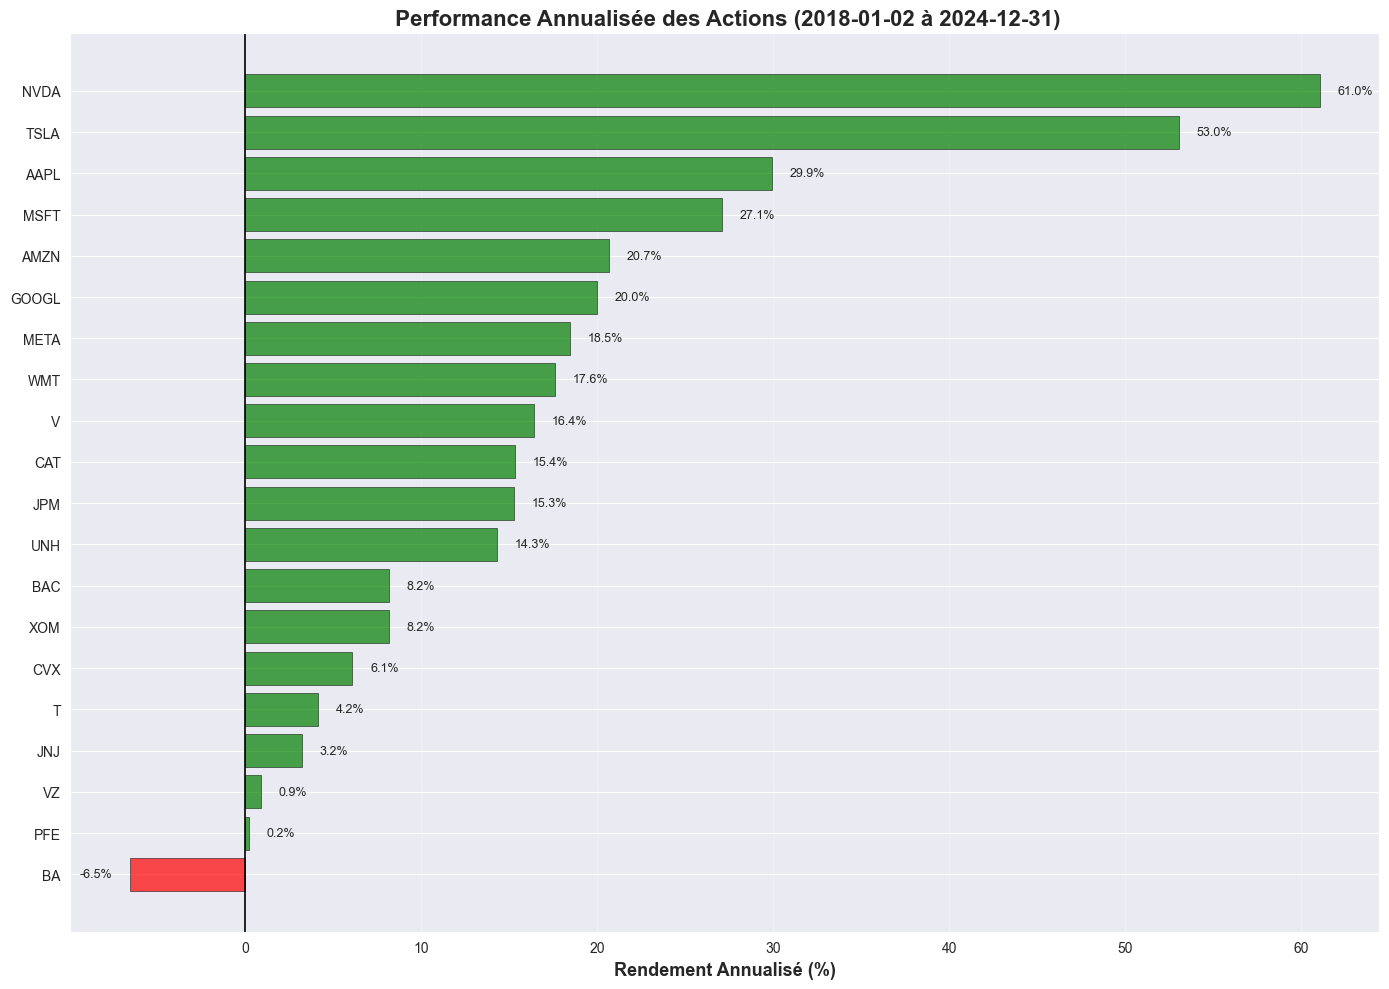

 Graphique 2/4: Performance annualisée


In [11]:
# Visualisation 2: Performance annualisée
returns_data = []
for ticker in data['Ticker'].unique():
    ticker_data = data[data['Ticker'] == ticker].sort_values('Date')
    first_price = ticker_data['Close'].iloc[0]
    last_price = ticker_data['Close'].iloc[-1]
    days = len(ticker_data)
    
    total_return = (last_price / first_price) - 1
    annualized_return = ((1 + total_return) ** (252 / days)) - 1
    
    returns_data.append({
        'Ticker': ticker,
        'Rendement Total (%)': total_return * 100,
        'Rendement Annualisé (%)': annualized_return * 100
    })

returns_df = pd.DataFrame(returns_data).sort_values('Rendement Annualisé (%)', ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['green' if x > 0 else 'red' for x in returns_df['Rendement Annualisé (%)']]
bars = ax.barh(returns_df['Ticker'], returns_df['Rendement Annualisé (%)'], 
               color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Ajouter valeurs
for i, (ticker, val) in enumerate(zip(returns_df['Ticker'], returns_df['Rendement Annualisé (%)'])):
    ax.text(val + (1 if val > 0 else -1), i, f'{val:.1f}%', 
            va='center', ha='left' if val > 0 else 'right', fontsize=9)

ax.set_xlabel('Rendement Annualisé (%)', fontsize=13, fontweight='bold')
ax.set_title(f' Performance Annualisée des Actions ({start_date} à {end_date})', 
             fontsize=16, fontweight='bold')
ax.axvline(0, color='black', linewidth=1.2)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(" Graphique 2/4: Performance annualisée")


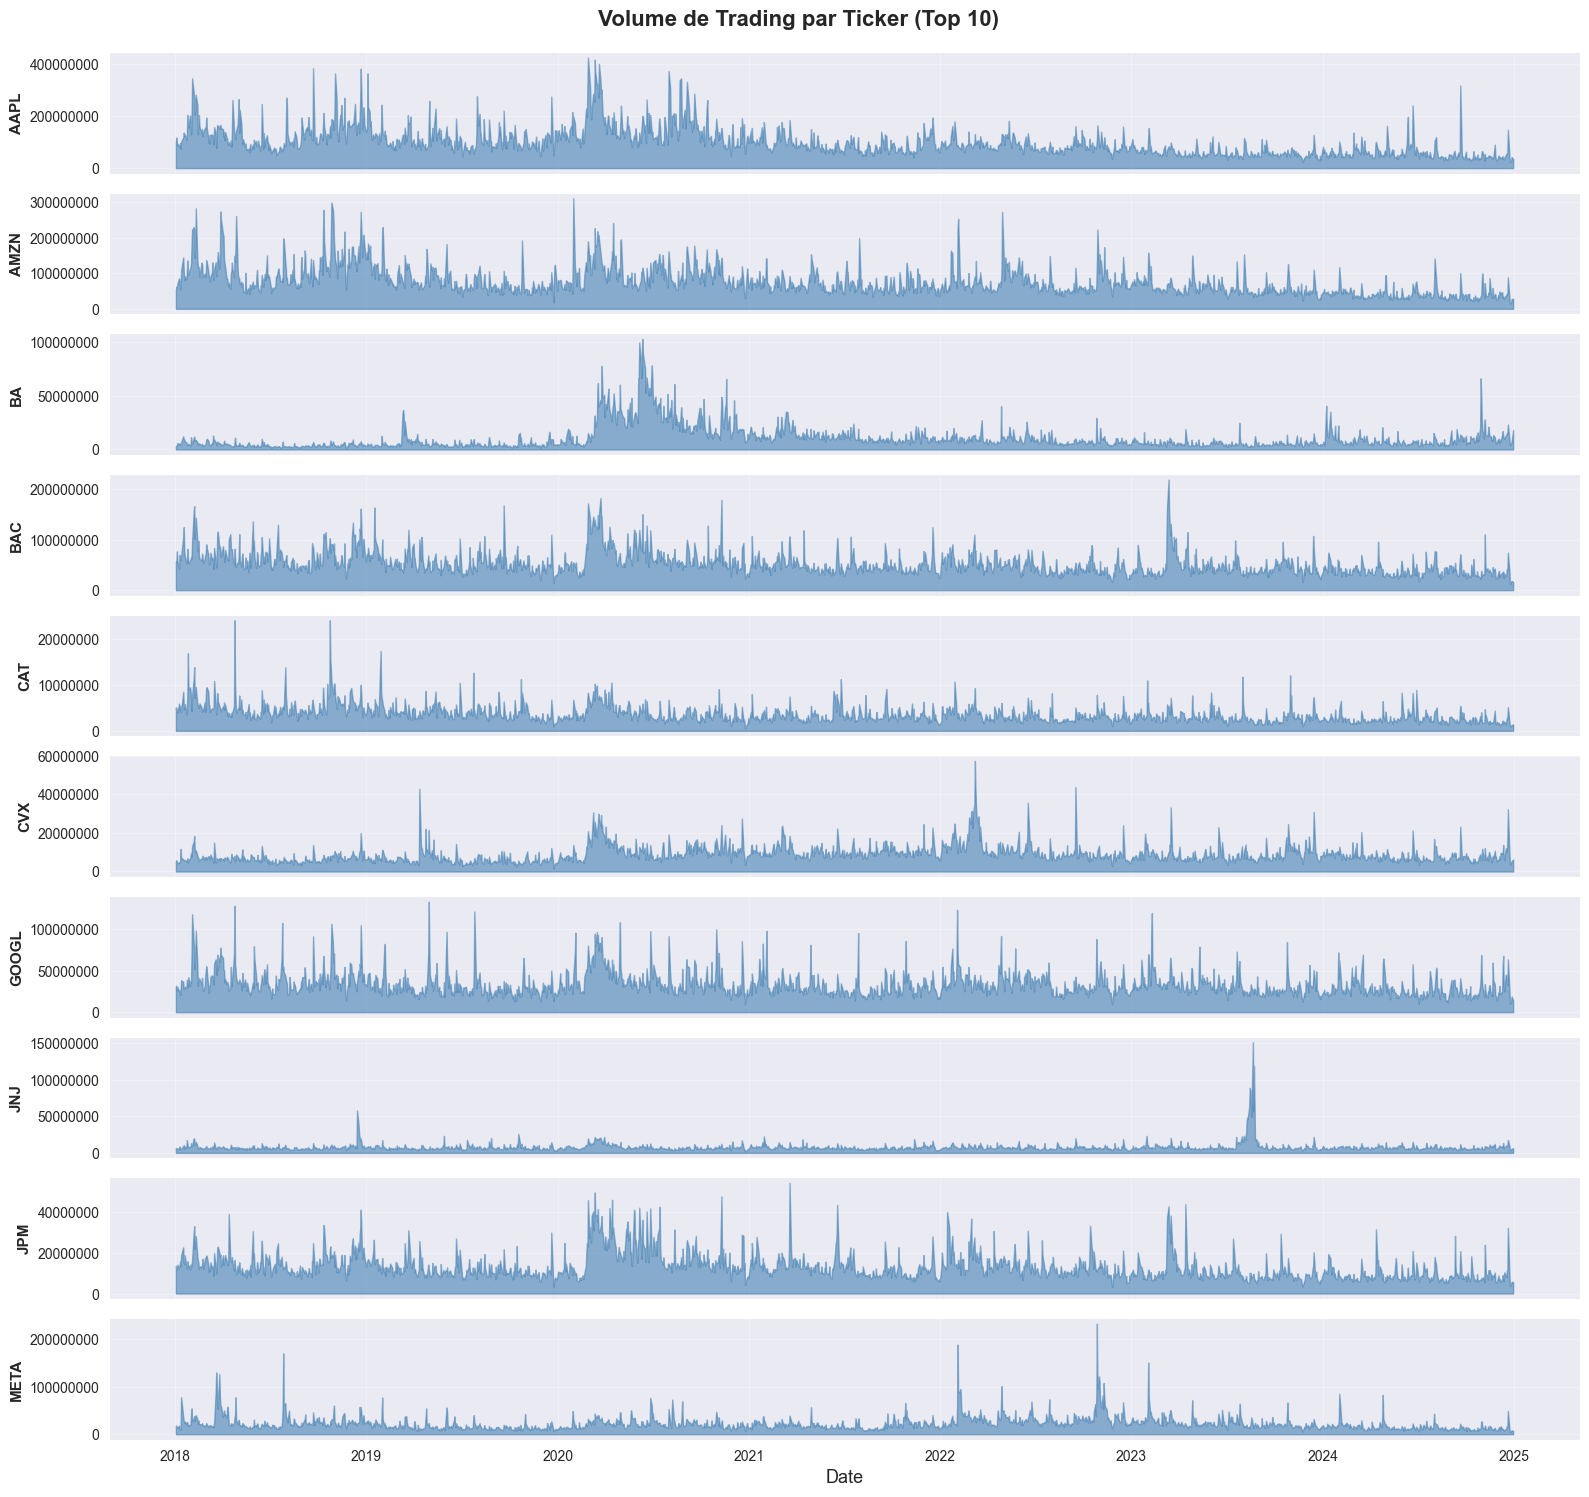

 Graphique 3/4: Volume de trading (top 10)


In [12]:
# Visualisation 3: Volume de trading par ticker (top 10)
top_tickers = sorted(data['Ticker'].unique())[:10]

fig, axes = plt.subplots(len(top_tickers), 1, 
                         figsize=(16, len(top_tickers) * 1.5), 
                         sharex=True)

if len(top_tickers) == 1:
    axes = [axes]

for i, ticker in enumerate(top_tickers):
    ticker_data = data[data['Ticker'] == ticker].sort_values('Date')
    axes[i].fill_between(ticker_data['Date'], ticker_data['Volume'], 
                          color='steelblue', alpha=0.6)
    axes[i].set_ylabel(ticker, fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].ticklabel_format(axis='y', style='plain')
    
plt.xlabel('Date', fontsize=13)
plt.suptitle(f' Volume de Trading par Ticker (Top {len(top_tickers)})', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f" Graphique 3/4: Volume de trading (top {len(top_tickers)})")


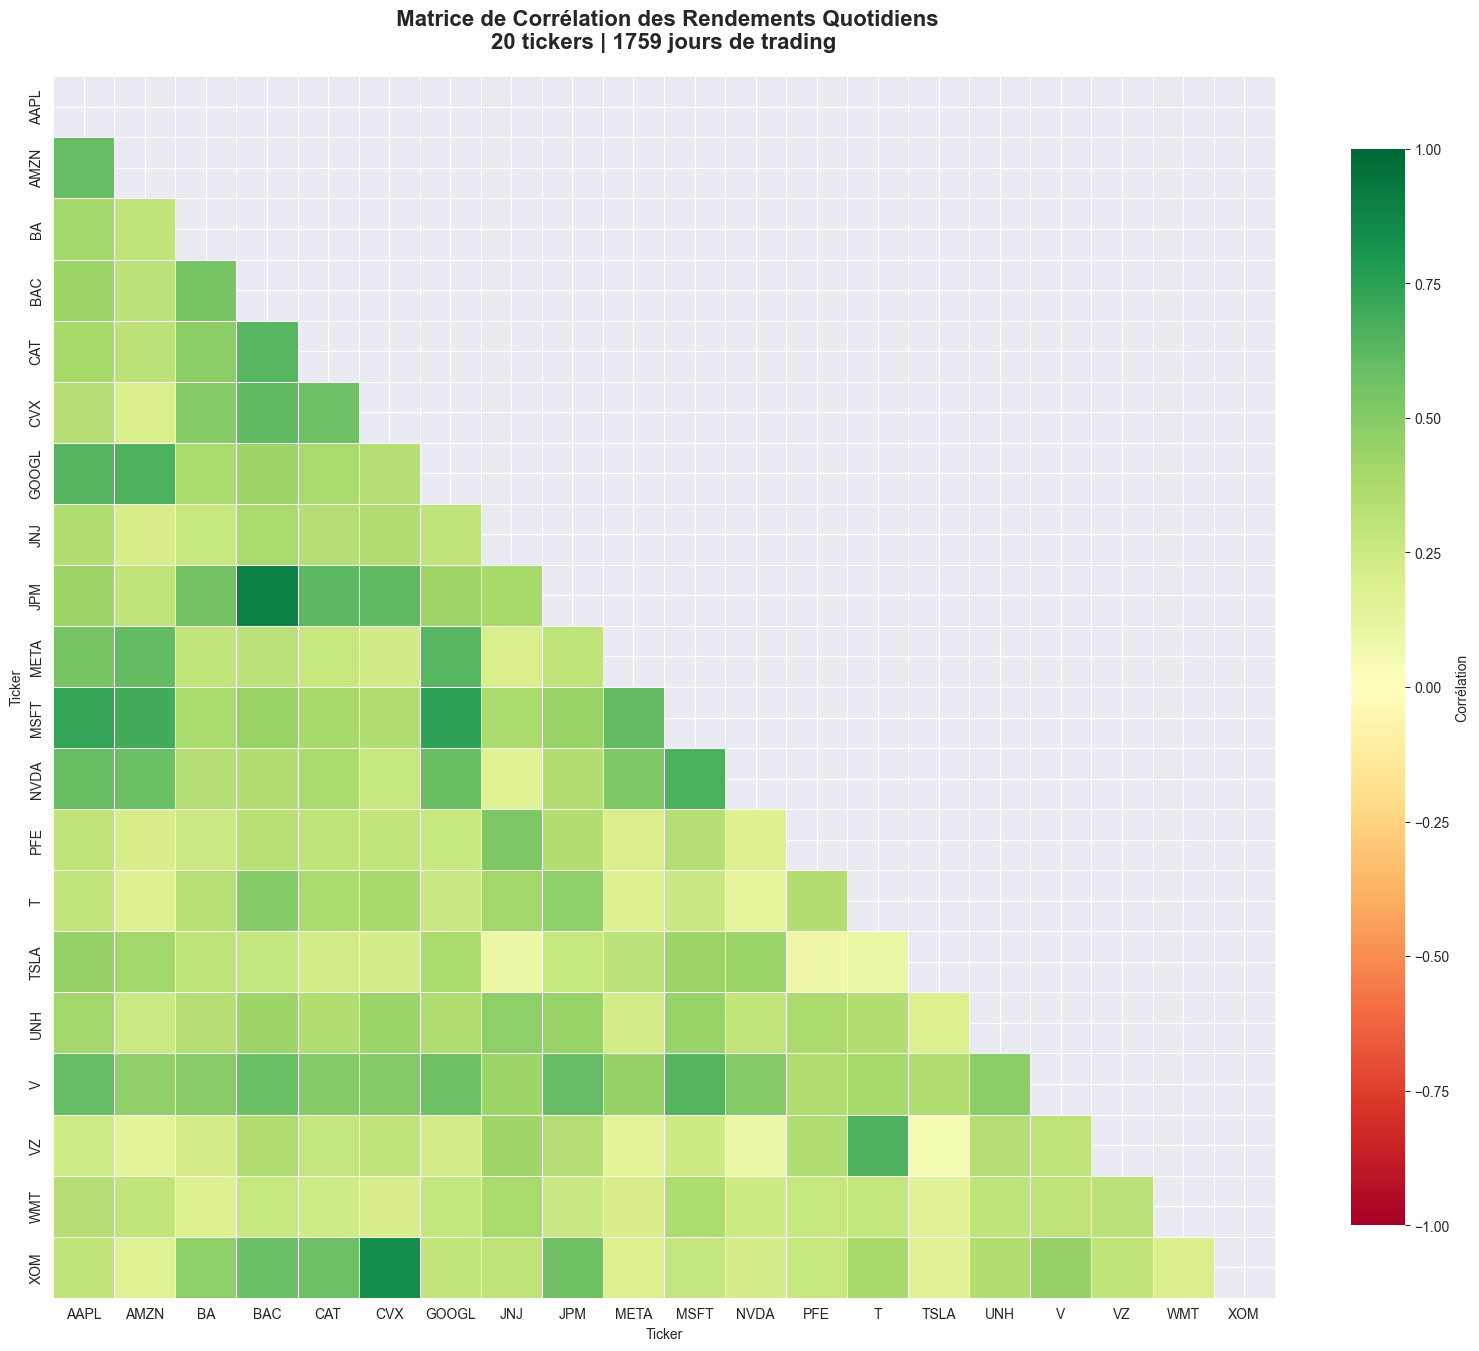

 Graphique 4/4: Matrice de corrélation

 Corrélation moyenne: 0.373
   Faible corrélation - Excellente diversification


In [13]:
# Visualisation 4: Matrice de corrélation
pivot = data.pivot(index='Date', columns='Ticker', values='Close')
daily_returns = pivot.pct_change().dropna()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(daily_returns.corr(), dtype=bool))
sns.heatmap(daily_returns.corr(), mask=mask, 
            annot=len(tickers) <= 15, fmt='.2f', 
            cmap='RdYlGn', center=0, 
            vmin=-1, vmax=1, square=True, ax=ax, 
            cbar_kws={'label': 'Corrélation', 'shrink': 0.8},
            linewidths=0.5)

ax.set_title(f' Matrice de Corrélation des Rendements Quotidiens\n' +
             f'{len(tickers)} tickers | {len(daily_returns)} jours de trading',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(" Graphique 4/4: Matrice de corrélation")

# Analyser corrélations
corr_matrix = daily_returns.corr()
avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
print(f"\n Corrélation moyenne: {avg_corr:.3f}")
if avg_corr > 0.7:
    print("    Corrélation élevée - Portfolio peu diversifié")
elif avg_corr > 0.4:
    print("   Corrélation modérée - Bonne diversification")
else:
    print("   Faible corrélation - Excellente diversification")

In [14]:
# Vérification qualité des données
print("\n" + "="*70)
print(" VÉRIFICATION DE LA QUALITÉ DES DONNÉES")
print("="*70 + "\n")

# Valeurs manquantes
missing = data.isnull().sum()
if missing.sum() == 0:
    print(" Aucune valeur manquante")
else:
    print("  Valeurs manquantes détectées:")
    for col, count in missing[missing > 0].items():
        pct = (count / len(data)) * 100
        print(f"  - {col}: {count} ({pct:.2f}%)")

# Doublons
duplicates = data.duplicated(subset=['Date', 'Ticker']).sum()
if duplicates == 0:
    print(" Aucun doublon détecté")
else:
    print(f"  {duplicates} doublons détectés (seront supprimés)")
    data = data.drop_duplicates(subset=['Date', 'Ticker'], keep='first')

# Valeurs négatives/nulles
price_cols = ['Open', 'High', 'Low', 'Close']
negative_prices = (data[price_cols] <= 0).sum().sum()
if negative_prices == 0:
    print(" Aucun prix négatif ou nul")
else:
    print(f" {negative_prices} prix négatifs/nuls détectés!")

# Cohérence OHLC
invalid_ohlc = ((data['Low'] > data['High']) | 
                (data['Close'] > data['High']) | 
                (data['Close'] < data['Low'])).sum()
if invalid_ohlc == 0:
    print(" Cohérence OHLC validée (Low ≤ Close ≤ High)")
else:
    print(f"  {invalid_ohlc} incohérences OHLC détectées")

print("\n Contrôle qualité terminé")


 VÉRIFICATION DE LA QUALITÉ DES DONNÉES

 Aucune valeur manquante
 Aucun doublon détecté
 Aucun prix négatif ou nul
  4 incohérences OHLC détectées

 Contrôle qualité terminé


In [15]:
# Investiguer les incohérences OHLC
print("\n🔍 INVESTIGATION DES INCOHÉRENCES OHLC:")
print("="*70)

# Identifier les lignes problématiques
invalid_mask = ((data['Low'] > data['High']) | 
                (data['Close'] > data['High']) | 
                (data['Close'] < data['Low']) |
                (data['Open'] > data['High']) |
                (data['Open'] < data['Low']))

invalid_rows = data[invalid_mask].copy()

if len(invalid_rows) > 0:
    print(f"\n❌ {len(invalid_rows)} lignes avec incohérences détectées:\n")
    display(invalid_rows[['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']])
    
    print("\n📊 Analyse des incohérences:")
    print(f"  - Tickers affectés: {invalid_rows['Ticker'].unique().tolist()}")
    print(f"  - Dates: {invalid_rows['Date'].min()} à {invalid_rows['Date'].max()}")
    
    # Analyser le type d'incohérence
    low_high_issue = (invalid_rows['Low'] > invalid_rows['High']).sum()
    close_high_issue = (invalid_rows['Close'] > invalid_rows['High']).sum()
    close_low_issue = (invalid_rows['Close'] < invalid_rows['Low']).sum()
    
    print(f"\n  Types d'incohérences:")
    if low_high_issue > 0:
        print(f"    - Low > High: {low_high_issue} cas")
    if close_high_issue > 0:
        print(f"    - Close > High: {close_high_issue} cas")
    if close_low_issue > 0:
        print(f"    - Close < Low: {close_low_issue} cas")
    
    print("\n🔧 CORRECTION AUTOMATIQUE:")
    print("  Stratégie: Ajuster High/Low pour respecter la logique OHLC")
    
    # Correction 1: Si Low > High, inverser
    swap_mask = data['Low'] > data['High']
    if swap_mask.sum() > 0:
        print(f"  - Inversion Low/High: {swap_mask.sum()} lignes")
        data.loc[swap_mask, ['Low', 'High']] = data.loc[swap_mask, ['High', 'Low']].values
    
    # Correction 2: Si Close > High, ajuster High
    close_high_mask = data['Close'] > data['High']
    if close_high_mask.sum() > 0:
        print(f"  - Ajustement High: {close_high_mask.sum()} lignes")
        data.loc[close_high_mask, 'High'] = data.loc[close_high_mask, 'Close']
    
    # Correction 3: Si Close < Low, ajuster Low
    close_low_mask = data['Close'] < data['Low']
    if close_low_mask.sum() > 0:
        print(f"  - Ajustement Low: {close_low_mask.sum()} lignes")
        data.loc[close_low_mask, 'Low'] = data.loc[close_low_mask, 'Close']
    
    # Correction 4: Si Open > High, ajuster High
    open_high_mask = data['Open'] > data['High']
    if open_high_mask.sum() > 0:
        print(f"  - Ajustement High (Open): {open_high_mask.sum()} lignes")
        data.loc[open_high_mask, 'High'] = data.loc[open_high_mask, 'Open']
    
    # Correction 5: Si Open < Low, ajuster Low
    open_low_mask = data['Open'] < data['Low']
    if open_low_mask.sum() > 0:
        print(f"  - Ajustement Low (Open): {open_low_mask.sum()} lignes")
        data.loc[open_low_mask, 'Low'] = data.loc[open_low_mask, 'Open']
    
    # Vérifier que tout est corrigé
    final_check = ((data['Low'] > data['High']) | 
                   (data['Close'] > data['High']) | 
                   (data['Close'] < data['Low']) |
                   (data['Open'] > data['High']) |
                   (data['Open'] < data['Low'])).sum()
    
    print(f"\n✅ VÉRIFICATION POST-CORRECTION:")
    if final_check == 0:
        print(f"  ✅ TOUTES les incohérences ont été corrigées!")
        print(f"  ✅ Dataset maintenant 100% cohérent")
    else:
        print(f"  ⚠️  {final_check} incohérences restantes (vérification manuelle requise)")
else:
    print("✅ Aucune incohérence OHLC détectée")

print("="*70)



🔍 INVESTIGATION DES INCOHÉRENCES OHLC:

❌ 4 lignes avec incohérences détectées:



Price,Date,Ticker,Open,High,Low,Close,Volume
23138,2019-01-11,PFE,29.151489,29.530260,29.027529,29.530260,21064506
33466,2018-02-08,T,15.853890,15.879675,15.286605,15.286605,60563732
33494,2018-03-21,T,15.617521,15.686283,15.471402,15.471402,23086853
34526,2022-04-26,T,15.928165,16.091950,15.805325,15.805325,50825900



📊 Analyse des incohérences:
  - Tickers affectés: ['PFE', 'T']
  - Dates: 2018-02-08 00:00:00 à 2022-04-26 00:00:00

  Types d'incohérences:
    - Close > High: 1 cas
    - Close < Low: 3 cas

🔧 CORRECTION AUTOMATIQUE:
  Stratégie: Ajuster High/Low pour respecter la logique OHLC
  - Ajustement High: 1 lignes
  - Ajustement Low: 3 lignes

✅ VÉRIFICATION POST-CORRECTION:
  ✅ TOUTES les incohérences ont été corrigées!
  ✅ Dataset maintenant 100% cohérent


In [16]:
# Sauvegarder les données
print("\n" + "="*70)
print(" SAUVEGARDE DES DONNÉES")
print("="*70 + "\n")

output_dir = config.data_dir / 'raw'
output_dir.mkdir(parents=True, exist_ok=True)

# Fichier principal
output_path = output_dir / 'financial_data_full.csv'
data.to_csv(output_path, index=False)
file_size_mb = output_path.stat().st_size / (1024 * 1024)
print(f" Données sauvegardées: {output_path}")
print(f"   Taille: {len(data):,} lignes × {len(data.columns)} colonnes ({file_size_mb:.2f} MB)")



 SAUVEGARDE DES DONNÉES

 Données sauvegardées: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\raw\financial_data_full.csv
   Taille: 35,200 lignes × 7 colonnes (3.30 MB)


In [17]:
# Métadonnées
collected_tickers = set(data['Ticker'].unique())
missing_tickers = set(tickers) - collected_tickers

metadata = {
    'collection_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'start_date': start_date,
    'end_date': end_date,
    'duration_years': round(years, 2),
    'tickers_requested': len(tickers),
    'tickers_collected': len(collected_tickers),
    'tickers_missing': list(missing_tickers),
    'total_rows': len(data),
    'columns': list(data.columns),
    'date_range_actual': {
        'min': str(data['Date'].min()),
        'max': str(data['Date'].max())
    },
    'quality_checks': {
        'missing_values': int(missing.sum()),
        'duplicates': int(duplicates),
        'negative_prices': int(negative_prices),
        'invalid_ohlc': int(invalid_ohlc)
    },
    'statistics': {
        'avg_correlation': round(float(avg_corr), 4),
        'avg_trading_days_per_ticker': round(float(jours.mean()), 1),
        'completeness_pct': round(float(jours.min() / trading_days_expected * 100), 2)
    }
}

metadata_path = output_dir / 'collection_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f" Métadonnées sauvegardées: {metadata_path}")

# Statistiques par ticker
stats_path = output_dir / 'tickers_statistics.csv'
stats_df.to_csv(stats_path, index=False)
print(f" Statistiques sauvegardées: {stats_path}")


 Métadonnées sauvegardées: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\raw\collection_metadata.json
 Statistiques sauvegardées: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\raw\tickers_statistics.csv


In [19]:
# Résumé final
print("\n" + "="*70)
print("🎉 COLLECTE DE DONNÉES TERMINÉE AVEC SUCCÈS!")
print("="*70)
print(f"✅ {len(data):,} lignes collectées")
print(f"✅ {data['Ticker'].nunique()} tickers réussis (sur {len(tickers)} demandés)")
print(f"✅ Période: {start_date} → {end_date} ({years:.1f} années)")
print(f"✅ COVID-19 inclus: Oui (Mars 2020 - Juin 2021)")
print(f"✅ Complétude: {(jours.min() / trading_days_expected * 100):.1f}%")

# ✅ CORRECTION: Conversion explicite en int
quality_level = ['Insuffisante', 'Bonne', 'Excellente']
quality_index = int(jours.min() >= trading_days_expected * 0.8) + int(jours.min() >= trading_days_expected * 0.9)
print(f"✅ Qualité: {quality_level[quality_index]}")

print()
print("📁 Fichiers générés:")
print(f"  - {output_path.name} ({file_size_mb:.2f} MB)")
print(f"  - {metadata_path.name}")
print(f"  - {stats_path.name}")
print()
print("📋 PROCHAINE ÉTAPE:")
print("   → Lancer 02_technical_indicators.ipynb")
print("   → Calcul HMA, RSI, MACD, etc.")
print("="*70)



🎉 COLLECTE DE DONNÉES TERMINÉE AVEC SUCCÈS!
✅ 35,200 lignes collectées
✅ 20 tickers réussis (sur 20 demandés)
✅ Période: 2018-01-02 → 2024-12-31 (7.0 années)
✅ COVID-19 inclus: Oui (Mars 2020 - Juin 2021)
✅ Complétude: 99.9%
✅ Qualité: Excellente

📁 Fichiers générés:
  - financial_data_full.csv (3.30 MB)
  - collection_metadata.json
  - tickers_statistics.csv

📋 PROCHAINE ÉTAPE:
   → Lancer 02_technical_indicators.ipynb
   → Calcul HMA, RSI, MACD, etc.
